## 🎯 Objective

The objective of this notebook is to build and understand a machine learning–based fraud detection system using transactional data.

This notebook focuses on:
- Understanding real-world fraud patterns through exploratory data analysis (EDA)
- Performing data cleaning and feature engineering on highly imbalanced financial data
- Training a baseline machine learning classification model to identify fraudulent transactions
- Evaluating model performance using appropriate classification metrics

This notebook is created as a **learning and practice exercise** to understand how fraud detection models are developed and evaluated in real-world financial systems.



### 🧠 Problem Context & Workflow Overview

Financial institutions process millions of transactions every day, making manual fraud detection impossible.  
Machine learning models are used to automatically analyze transaction patterns and identify potentially fraudulent activities in real time.

In this project, we aim to simulate a real-world fraud detection workflow by analyzing a large, highly imbalanced transaction dataset and training a classification model to predict fraudulent transactions.

##### 🔍 Key Challenges Addressed
- Extremely imbalanced dataset with very few fraud cases
- Complex transaction behavior across different transaction types
- Need for meaningful feature engineering based on account balances

##### 🧩 Overall Workflow
The steps followed in this notebook are:
1. Data loading and initial inspection
2. Exploratory Data Analysis (EDA)
3. Data cleaning and preprocessing
4. Feature engineering
5. Model training using a machine learning pipeline
6. Model evaluation and interpretation
7. Saving the trained model for deployment 

In [53]:
import pandas as p
import numpy as n
import matplotlib as plt
import seaborn as s
import os

#### 🛠️ Import of Libraries & Used

- **Pandas**: For loading, cleaning, and analyzing transaction data efficiently.  
- **NumPy**: For fast numerical computations and array operations.  
- **Matplotlib**: For basic plots to visualize data distributions.  
- **Seaborn**: For advanced statistical plots and correlation heatmaps.  
- **OS**: To handle file paths and directories reliably. 

**Warnings**: To suppress unnecessary warnings for cleaner output.

In [54]:
import warnings
warnings.filterwarnings("ignore")
s.set_style("whitegrid")

##### 📂 Loading the Dataset
We load the transaction dataset using Pandas to begin exploration and analysis.

In [55]:
df = p.read_csv("../Data/fraud_data.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


## Process of EDA & Data Cleaning Start,s.

##### ℹ️ Initial Inspection
Check the dataset structure, column names, data types, and non-null counts to understand its quality.

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [57]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

##### 📊 Basic Statistical Summary
View summary statistics for numerical columns to identify ranges, means, min, max and potential outliers(Q1, Q2, Q3).

In [58]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


##### 🔢 Target Variable Distribution
Check the distribution of the target variable `isFraud` and `isFlaggedFraud` to understand class imbalance.

In [59]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [60]:
df["isFlaggedFraud"].value_counts() 

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

##### 🧼 Missing Values
Check whether the dataset contains any missing values.

In [61]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

##### 📊 Fraud Percentage
Calculate how rare fraud transactions are in the dataset.

In [62]:
df["isFraud"].value_counts()[1] / df["isFraud"].value_counts()[0]*100

np.float64(0.129248881917699)

##### 📉 Fraud Percentage (Readable Format)
Display the fraud percentage in a clear and readable format.

In [63]:
per_fraud = round((df["isFraud"].value_counts()[1] / df["isFraud"].value_counts()[0]*100),2)
print(f"Percentage of fraud transactions: {per_fraud} %")

Percentage of fraud transactions: 0.13 %


##### 📦 Transaction Types
Visualize the number of transactions for each transaction type.

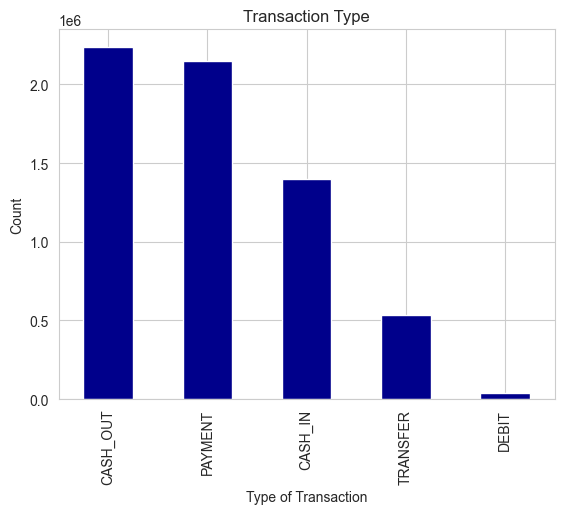

In [64]:
df["type"].value_counts().plot(kind='bar',title="Transaction Type",color='darkblue')
plt.pyplot.xlabel("Type of Transaction")
plt.pyplot.ylabel("Count")
plt.pyplot.show()

##### 🚨 Fraud Analysis by Transaction Type

This step analyzes fraud patterns across different transaction types.  
We calculate the average fraud rate for each transaction type and visualize it to identify high-risk transaction categories.

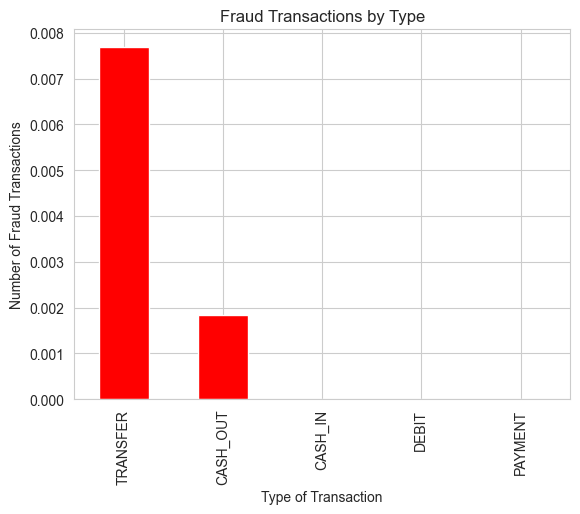

In [65]:
fraud_types = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_types.plot(kind='bar',title="Fraud Transactions by Type",color='red')
plt.pyplot.xlabel("Type of Transaction")
plt.pyplot.ylabel("Number of Fraud Transactions")
plt.pyplot.show()

##### 🔢 Fraud Type (Numerical Analysis)

Analyze fraud patterns by transaction type using numerical values.

In [66]:
fraud_types

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

#### 💰 Transaction Amount Analysis

This step analyzes the statistical distribution of transaction amounts and visualizes it using a log scale to better handle extreme values and skewed data.

In [67]:
df['amount'].describe().astype(n.int64)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

#### 📊 Transaction Amount Distribution (Log Scale)

We use a log transformation (`log1p`) to handle skewed transaction amounts.  
This makes the data easier to visualize and reduces the effect of very large values.  
The histogram with KDE shows how transactions are spread after transformation.

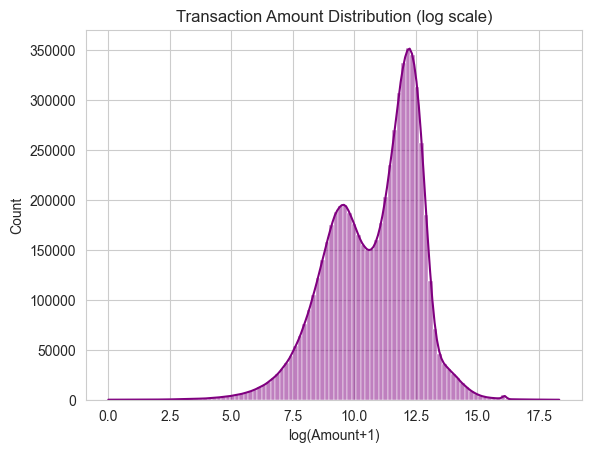

In [68]:
s.histplot(n.log1p(df['amount']),bins=100,kde=True,color='purple')
plt.pyplot.title("Transaction Amount Distribution (log scale)") 
plt.pyplot.xlabel("log(Amount+1)")  
plt.pyplot.show()

#### 📊 Transaction Amount vs Fraud Status (Boxplot)

**Notebook:** `FD_model.ipynb`

**Objective:**  
Quickly compare transaction amount distributions for **fraud** vs **non-fraud** cases.

**Why it matters:**  
- Detect spending patterns & outliers 💡  
- Compare behavior across fraud labels 🔍  
- Improve feature understanding before modeling 🚀

**Approach:**  
- Filter amounts `< 100,000` to limit extreme outliers  
- Visualize using a boxplot grouped by `isFraud`

*Supports efficient EDA and better fraud model decisions.*


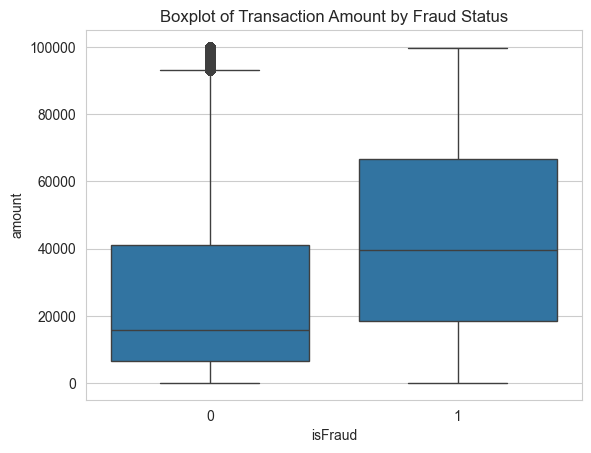

In [69]:
s.boxplot(data=df[df['amount']<100000], x='isFraud', y='amount')
plt.pyplot.title("Boxplot of Transaction Amount by Fraud Status")
plt.pyplot.show() 

## Feature Engineering

#### 💡 Balance Difference Calculation

In financial transaction datasets, it’s often critical to track how balances change before and after a transaction.  
Here we compute two derived features:

- **`balance_diff`** → Difference between the sender’s original balance (`oldbalanceOrg`) and their new balance (`newbalanceOrig`).  
  - Helps us detect inconsistencies, fraud patterns, or anomalies in outgoing transactions.

- **`balance_diff_Destination`** → Difference between the receiver’s new balance (`newbalanceDest`) and their old balance (`oldbalanceDest`).  
  - Useful for validating whether the destination account reflects the expected incoming funds.

In [70]:
df["balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"] 
df['balance_diff_Destination'] = df['newbalanceDest'] - df['oldbalanceDest']

##### 🎯 Why this matters
- These engineered features are **key signals** in fraud detection and anomaly detection models.  
- They allow us to check whether money movement is consistent with transaction rules.  
- In ML pipelines, such features often improve model accuracy by highlighting irregularities.


In [71]:
df['balance_diff'].describe().astype(n.int64)

count     6362620
mean       -21230
std        146643
min      -1915267
25%             0
50%             0
75%         10150
max      10000000
Name: balance_diff, dtype: int64

###### df['balance_diff'].describe().astype(n.int64)
- We use `.describe()` to quickly view stats (count, mean, min, max, quartiles) of `balance_diff`.  
- Casting to `int64` ensures clean integer outputs for easier reporting and analysis.

In [72]:
(df['balance_diff']<0).sum()
print("Number of transactions with negative balance difference are (Original):", (df['balance_diff']<0).sum())

Number of transactions with negative balance difference are (Original): 1399253


#### ⚠️ Negative Balance Differences
We check how many transactions have `balance_diff < 0`.  
This flags cases where the sender’s new balance is unexpectedly higher than the old balance,  
which may indicate **data errors or potential fraud patterns**.

In [73]:
(df['balance_diff_Destination']<0).sum()

np.int64(1238864)

#### 📊 Destination Balance Check
We count how many transactions have `balance_diff_Destination < 0`  
→ flags cases where the receiver’s new balance is less than the old one (possible anomaly).  

Finally, `df.head()` shows the first 5 rows for a quick data preview.


In [74]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff,balance_diff_Destination
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


#### 📈 Frauds Over Time
We group transactions where `isFraud == 1` by `step` (time unit) and count them.  
Plotting these counts shows how fraud cases evolve over time, helping us spot **patterns or spikes**.


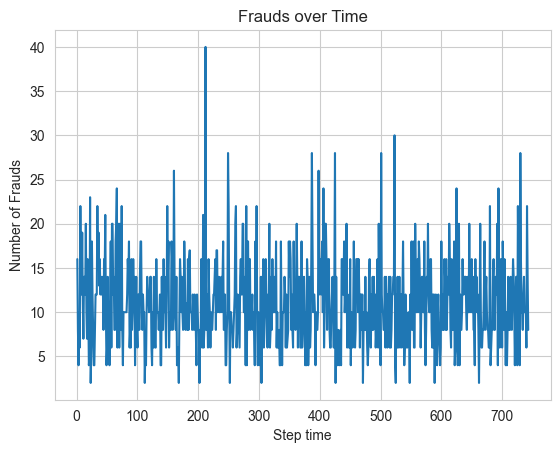

In [75]:
frauds_per_step = df[df['isFraud']==1]['step'].value_counts().sort_index()
plt.pyplot.plot(frauds_per_step.index, frauds_per_step.values, label='Frauds per Step')
plt.pyplot.title("Frauds over Time")
plt.pyplot.xlabel("Step time")
plt.pyplot.ylabel("Number of Frauds")
plt.pyplot.grid(True)
plt.pyplot.show()

#### 🗑️ Dropping Column
- We remove the `step` column using `df.drop(..., inplace=True)`.  
- This is part of the **feature engineering process**.  
- Dropping unused or redundant columns is important because:
  - ✅ Reduces noise in the dataset  
  - ✅ Improves model efficiency and training speed  
  - ✅ Ensures focus on features that truly add predictive power  


In [76]:
df.drop(columns="step",inplace=True)

#### 📌 Top Senders
- We use `value_counts()` on `nameOrig` to find the most frequent sender accounts.  
- `.head(10)` returns the **top 10 senders** by transaction volume.  
- This helps identify accounts with unusually high activity, which may be relevant for **fraud detection** or **behavior analysis**.


In [77]:
top_senders = df['nameOrig'].value_counts().head(10) 

In [78]:
top_senders

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

#### 📌 Top Receivers
- We use `value_counts()` on `nameDest` to find the most frequent receiver accounts.  
- `.head(10)` returns the **top 10 receivers** by transaction volume.  
- This helps identify accounts with unusually high incoming activity, which may be relevant for **fraud detection** or **network analysis**.


In [79]:
top_receivers = df['nameDest'].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

#### 🚨 Top Fraudulent Senders
- We filter transactions where `isFraud == 1`.  
- Then use `value_counts()` on `nameOrig` to find accounts most often flagged as fraud.  
- `.head(10)` returns the **top 10 sender accounts** involved in fraudulent activity.  
- This helps identify **high-risk users** for deeper investigation or monitoring.


In [80]:
fraud_users = df[df['isFraud']==1]['nameOrig'].value_counts().head(10)
fraud_users

nameOrig
C1280323807    1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C1039979813    1
C2089752665    1
C1614818636    1
C40604503      1
C1970706589    1
Name: count, dtype: int64

#### 🔎 Fraud Transaction Types
- In earlier analysis, we observed that most fraud cases occur in **TRANSFER** and **CASH_OUT** transactions.  
- Therefore, we filter only these two types to focus on the **highest-risk categories**.  
- Using `value_counts()` shows how many fraudulent cases occur in each type.  
- This helps identify which transaction modes are **most vulnerable** to fraud and guides targeted prevention strategies.


In [81]:
fraud_types = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

#### 📊 Fraud Distribution by Transaction Type
- We use `countplot` to visualize **TRANSFER** and **CASH_OUT** transactions.  
- `hue='isFraud'` separates fraudulent vs. non-fraudulent cases.  
- The chart shows how fraud is distributed across these two high-risk transaction types,  
  helping us compare vulnerability between them.


Text(0.5, 1.0, 'Fraud Distribution in Transfer and Cash Out')

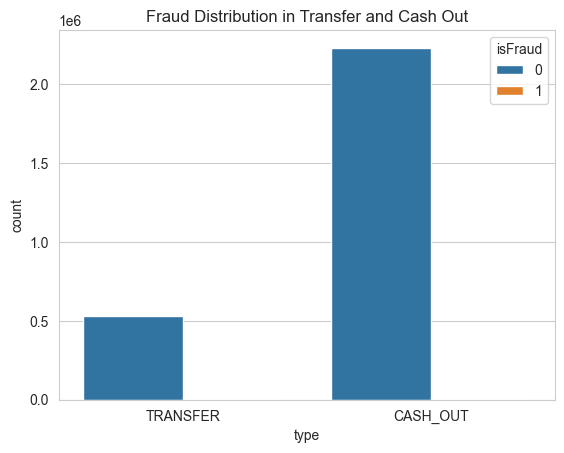

In [82]:
s.countplot(data=fraud_types, x='type', hue='isFraud')
plt.pyplot.title("Fraud Distribution in Transfer and Cash Out")


#### 📊 Correlation Matrix
- We calculate correlations between key numeric features (`amount`, balances, and `isFraud`).  
- This shows how strongly each variable is related to fraud and to each other.  
- Useful for **feature selection** and understanding which factors may influence fraudulent activity.


In [83]:
corr = df[['amount',"oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()

In [84]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


#### 🌡️ Correlation Heatmap
- We plot the correlation matrix using `heatmap` with `coolwarm` color scale.  
- `annot=True` shows correlation values, formatted to 2 decimals.  
- This helps visualize relationships between features and highlights which variables are most linked to fraud.


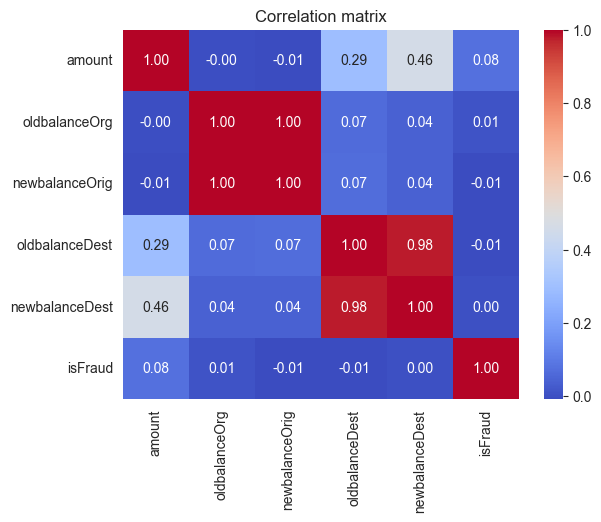

In [85]:
s.heatmap(corr, annot=True, cmap='coolwarm',fmt=".2f")
plt.pyplot.title("Correlation matrix")
plt.pyplot.show()

#### 🔍 Zero Balance After Transaction
- We filter transactions where:
  - `oldbalanceOrg > 0` → sender had money before the transaction  
  - `newbalanceOrig == 0` → sender’s balance becomes zero after the transaction  
  - `type` is **TRANSFER** or **CASH_OUT** → the two fraud-prone transaction types  
- This helps detect suspicious cases where accounts are **emptied completely**, a common fraud pattern.


In [86]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]


- `len(zero_after_transfer)` counts transactions where sender’s balance drops to zero.  
- Focused on **TRANSFER** and **CASH_OUT**, highlighting suspicious account-emptying patterns linked to fraud.


In [87]:
len(zero_after_transfer)

1188074


- `zero_after_transfer.head()` shows the first 5 suspicious transactions.  
- Useful for quickly inspecting account details where balances dropped to zero after **TRANSFER** or **CASH_OUT**.


In [88]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff,balance_diff_Destination
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


## 🤖 Fraud Detection Model Presentation


#### ⚙️ Machine Learning Setup: Libraries & Tools

- **train_test_split** → divides dataset into training and testing sets for model validation  
- **LogisticRegression** → baseline classification model for fraud detection  
- **StandardScaler** → standardizes numerical features to improve model performance  
- **OneHotEncoder** → converts categorical variables into numerical format  
- **Pipeline** → integrates preprocessing and modeling into a single workflow  
- **ColumnTransformer** → applies transformations to selected columns efficiently  
- **Evaluation Metrics**:  
  - **classification_report** → precision, recall, F1-score  
  - **confusion_matrix** → breakdown of fraud vs. non-fraud predictions  
  - **accuracy_score** → overall correctness of predictions


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [90]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff,balance_diff_Destination
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


#### 🧹 Preparing Model Dataset
- Dropped columns: **`nameOrig`**, **`nameDest`**, and **`isFlaggedFraud`**.  
- Reason:
  - `nameOrig` / `nameDest` → identifiers, not useful for prediction.  
  - `isFlaggedFraud` → not relevant for training (rarely flagged, adds noise).  
- Result: cleaner dataset (**df_model**) with only meaningful features for fraud detection.


In [91]:
df_model = df.drop(columns=['nameOrig', 'nameDest','isFlaggedFraud'], axis=1)

#### 👀 Preview of Model Dataset
- `df_model.head()` shows the first 5 rows of the cleaned dataset.  
- Useful for verifying that dropped columns (`nameOrig`, `nameDest`, `isFlaggedFraud`) are removed.  
- Confirms the dataset is ready for **model training**.


In [92]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff,balance_diff_Destination
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


#### 🗂 Feature Groups
- **Categorical Features** → `['type']`  
- **Numerical Features** → `['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']`  
- Separation helps apply the right preprocessing:
  - Encode categorical (`OneHotEncoder`)  
  - Scale numerical (`StandardScaler`)


In [93]:
catrgorical = ['type']
numerical = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

#### 🎯 Features & Target Split
- **y** → target variable (`isFraud`)  
- **X** → feature set (all other columns except `isFraud`)  
- This separation is essential for training the fraud detection model.


In [94]:
y = df_model['isFraud']
X = df_model.drop(['isFraud'], axis=1)

### 🤖 Train-Test Split
- Split data into **80% training** and **20% testing**.  
- `random_state=42` → ensures reproducibility.  
- `stratify=y` → keeps fraud/non-fraud ratio balanced in both sets.  


In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### 🛠 Preprocessing Setup
- Built a **ColumnTransformer** to handle features:
  - **Numerical** → scaled with `StandardScaler`  
  - **Categorical** → encoded with `OneHotEncoder`  
- Ensures all features are properly transformed before feeding into the model.


In [96]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numrcl', StandardScaler(), numerical),
        ('catgrcal', OneHotEncoder(handle_unknown='ignore'), catrgorical)
    ], remainder='drop'
)

#### 🏗️ Model Pipeline
- Combines preprocessing + classification into one workflow.  
- **Preprocessor** → scales numerical + encodes categorical features.  
- **LogisticRegression** → fraud detection model with:
  - `class_weight='balanced'` → handles class imbalance  
  - `max_iter=1000` → ensures convergence  


In [97]:
Pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced',max_iter=1000))
])

### 🚀 Model Training
- `Pipeline.fit(X_train, y_train)` trains the fraud detection model.  
- Applies preprocessing (scaling + encoding) and fits **Logistic Regression** on training data.  
- Result: a trained pipeline ready for evaluation on test data.


In [98]:
Pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numrcl', ...), ('catgrcal', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 🔮 Model Prediction
- `y_pred = Pipeline.predict(X_test)` generates fraud predictions on the test set.  
- Predicted values will be **0 (non-fraud)** or **1 (fraud)**.  
- These predictions will be compared with `y_test` to evaluate model performance.


In [99]:
y_pred = Pipeline.predict(X_test)

#### 📊 Fraud Detection Model Evaluation

- **Goal** → Detect fraudulent transactions using Logistic Regression.  
- **Metrics** → Precision, Recall, F1-score, Accuracy

#### 📈 Interpretation
- Class 0 (Non-Fraud) → Very high precision (1.00) and strong recall (0.95).
- Class 1 (Fraud) → Very low precision (0.02) but high recall (0.94).
- Accuracy → Overall 95%, driven mostly by the majority class (non-fraud).
- Macro Avg → Shows imbalance: precision is low due to poor fraud detection.
- Weighted Avg → Skewed by majority class, looks strong but hides weak fraud precision.


In [100]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.94      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.94      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



#### 🔢 Confusion Matrix

|                | Predicted Non-Fraud | Predicted Fraud |
|----------------|----------------------|-----------------|
| **Actual Non-Fraud (0)** | 1,202,359 (TN) | 68,522 (FP) |
| **Actual Fraud (1)**     | 93 (FN)        | 1,550 (TP)  |

### 📈 Interpretation
- **True Negatives (TN)** → 1,202,359 non-fraud cases correctly identified.  
- **False Positives (FP)** → 68,522 transactions wrongly flagged as fraud.  
- **False Negatives (FN)** → 93 fraud cases missed.  
- **True Positives (TP)** → 1,550 fraud cases correctly detected.  

👉 The model catches most frauds (high recall) but generates many false alarms (low precision).


In [101]:
confusion_matrix(y_test, y_pred)

array([[1202359,   68522],
       [     93,    1550]])

#### ✅ Model Accuracy
- `Pipeline.score(X_test, y_test) * 100` gives the **accuracy percentage** of the model on test data.  
- In this case → **95% accuracy**.  
- Meaning: the model correctly predicts fraud/non-fraud for 95 out of 100 transactions.


In [102]:
Pipeline.score(X_test, y_test)*100

94.60796024279307

#### 💾 Model Save Path
- Using `joblib` to save the trained pipeline.  
- `Model_path` → `"Model/fraud_detection_model.pkl"`  
- This defines where the fraud detection model will be stored for later use.


In [103]:
import joblib

Model_path = os.path.join("Model","fraud_detection_model.pkl")